In [1]:
import sys
print(sys.executable)

c:\Users\suzan\OneDrive\Documents\Work Projects\Generating_Questions\.venv311\Scripts\python.exe


In [2]:
from bertopic import BERTopic
import pandas as pd
import matplotlib.pyplot as plt
from umap import UMAP
from hdbscan import HDBSCAN

c:\Users\suzan\OneDrive\Documents\Work Projects\Generating_Questions\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def clean_txt(uncleaned_sentences):
    seen = set()
    sentences = []
    for line in uncleaned_sentences:
        cleaned = line.strip()

        # Remove only beginning+ending quote if both match
        if len(cleaned) >= 2 and cleaned[0] == cleaned[-1] and cleaned[0] in {"'", '"'}:
            cleaned = cleaned[1:-1].strip()

        if cleaned and cleaned not in seen:
            seen.add(cleaned)
            sentences.append(cleaned)

    return sentences

with open("questions.txt", "r", encoding="utf-8") as f:
    uncleaned_sentences = f.read().splitlines()
    sentences = clean_txt(uncleaned_sentences)


In [31]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer

sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
#Reduce high dimensions
umap_model = UMAP(n_neighbors=20, n_components=5, min_dist=0.0, metric="cosine")
hdbscan_model = HDBSCAN(
    min_cluster_size=5,
    min_samples=1,
    metric="euclidean",
    cluster_selection_method="eom"
)

vectorizer_model = CountVectorizer(
    stop_words="english",   # removes common English filler words
    ngram_range=(1, 2),     # helps capture short phrases
    min_df=2,               # ignore very rare terms
    max_df=0.8              # ignore overly frequent terms
)

ctfidf_model = ClassTfidfTransformer(
    reduce_frequent_words=True
)

topic_model = BERTopic(
    embedding_model=sentence_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    nr_topics="auto"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 902.21it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [32]:
topics, probs = topic_model.fit_transform(sentences)

In [65]:
topic_model.get_topic_info()

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,140,-1_life_my_to_is,happiness,"[life, my, to, is, of, others, the, should, it...",[Is it wrong to want a good life for myself if...
1,0,117,0_forgive_guilt_guilty_forgiveness,forgive,"[forgive, guilt, guilty, forgiveness, someone,...",[Should I forgive myself even if the people I ...
2,1,85,1_death_afterlife_beliefs_should,afterlife,"[death, afterlife, beliefs, should, medical, t...",[Should parents be allowed to refuse medical t...
3,2,74,2_meaning_life_does_faith,relationship,"[meaning, life, does, faith, religion, purpose...",[Does religion say suffering gives life meanin...
4,3,65,3_relationship_marriage_partner_in,community,"[relationship, marriage, partner, in, physical...",[Is it moral to prioritize my marriage over my...
5,4,46,4_family_my_for_pursue,it,"[family, my, for, pursue, money, with, to, sho...",[Is it wrong to spend money on therapy or self...
6,5,39,5_tell_it_mistake_confess,control,"[tell, it, mistake, confess, if, no, lie, dish...","[If I make a mistake that no one else notices,..."
7,6,31,6_defense_war_anger_revenge,violence,"[defense, war, anger, revenge, violence, ever,...",[Is it ever morally acceptable to use violence...
8,7,29,7_community_values_my_in,addiction,"[community, values, my, in, with, to, group, r...",[Is it okay to distance myself from a communit...
9,8,26,8_charity_give_wealth_money,anger,"[charity, give, wealth, money, donate, wealthy...",[Is it morally okay to spend money on self-car...


In [ ]:
topic_model.get_representative_docs(0)

['Should I forgive myself even if the people I hurt haven’t forgiven me?',
 "Do I have to forgive someone who hurt me if they haven't apologized or changed?",
 "Is it wrong to forgive myself for something I did if the person I hurt hasn't forgiven me?"]

In [36]:
topic_model.get_representative_docs(5)

["If I make a mistake that no one else notices, is it necessary to confess it if it doesn't hurt anyone?",
 'Is it okay to keep secrets from my partner if I believe the truth would cause unnecessary pain?',
 "Is it okay to tell a small lie to spare someone's feelings if the truth would cause unnecessary pain?"]

In [ ]:
df_sentences = pd.DataFrame({"Topics": topics, "Question": sentences})
df_sentences.head(10)

,Topics,Question
0,0,"﻿I don’t know what to do with my life, what ad..."
1,0,What is your process for making major life dec...
2,0,Do I have a moral obligation to take full resp...
3,0,Is it wrong to rely on others to fix my proble...
4,6,"According to religious teachings, am I account..."
5,-1,Should I feel morally responsible for not usin...
6,0,Is it ethical to avoid personal growth because...
7,4,Do I have a duty to set a good example for my ...
8,6,Is blaming external factors (like society or f...
9,6,What does my religion say about free will and ...


In [ ]:
new_topics = topic_model.reduce_outliers(
sentences,
topics,
strategy="embeddings",
threshold=0.15
)
topic_model.update_topics(sentences, topics=new_topics)
df_sentences["Topics"] = new_topics


2026-04-15 13:03:52,145 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [ ]:
# removing outliers
outlier_count = (df_sentences["Topics"] == -1).sum()
print(outlier_count)

df_sentences

0


,Topics,Question
0,0,"﻿I don’t know what to do with my life, what ad..."
1,0,What is your process for making major life dec...
2,0,Do I have a moral obligation to take full resp...
3,0,Is it wrong to rely on others to fix my proble...
4,6,"According to religious teachings, am I account..."
...,...,...
820,1,Should I forgive a family member for the sake ...
821,1,When does forgiving someone enable them to con...
822,1,Is it morally required to forgive someone who ...
823,1,Should I forgive myself for hurting someone el...


In [40]:
topic_model.visualize_topics()

In [41]:
topic_model.visualize_barchart(top_n_topics=32)

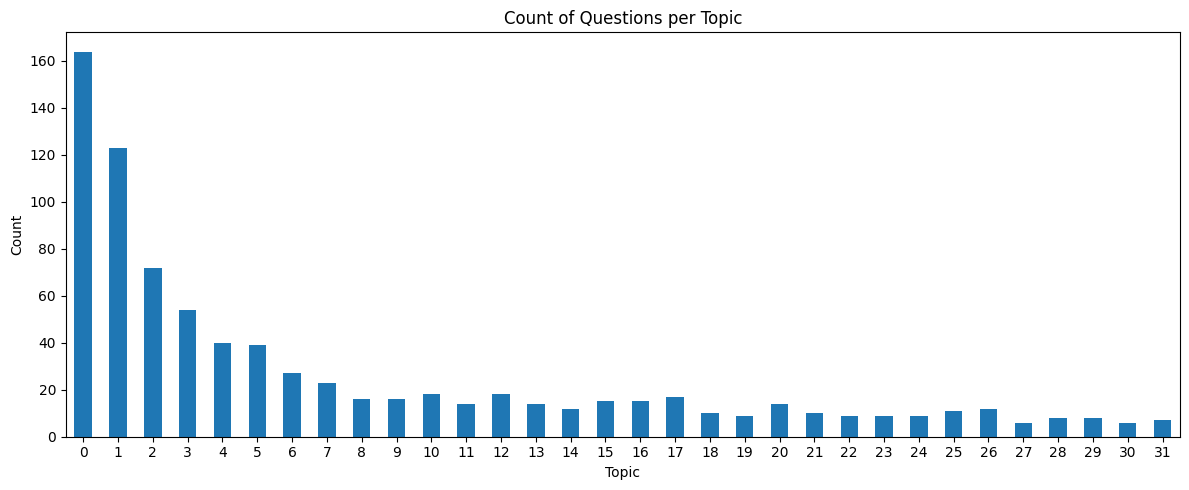

In [ ]:
topic_counts = df_sentences["Topics"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
topic_counts.plot(kind="bar")
plt.title("Count of Questions per Topic")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
def define_labels_for_topics(curr_df):
    topic_info = topic_model.get_topic_info()

    one_word_labels = {}
    used_labels = set()

    for topic_id in topic_info["Topic"]:
        if topic_id == -1:
            continue  # outlier topic

        # BERTopic returns (word, score) sorted by score descending
        word_scores = topic_model.get_topic(topic_id)

        # Pick the highest-score unigram not in blocked list; fallback to first entry
    
        label = word_scores[0][0]

        # Keep labels unique if duplicate top words appear across topics
        base = label
        n = 2
        while label in used_labels:
            label = f"{base}_{n}"
            n += 1

        used_labels.add(label)
        one_word_labels[topic_id] = label

    # Apply labels to BERTopic + dataframe
    topic_model.set_topic_labels(one_word_labels)
    curr_df["Topic_Label"] = curr_df["Topics"].map(one_word_labels).fillna("outlier")

    # Preview
    label_table = (
        curr_df[["Topics", "Topic_Label"]]
        .drop_duplicates()
        .sort_values("Topics")
    )

    return label_table

l_table = define_labels_for_topics(df_sentences)

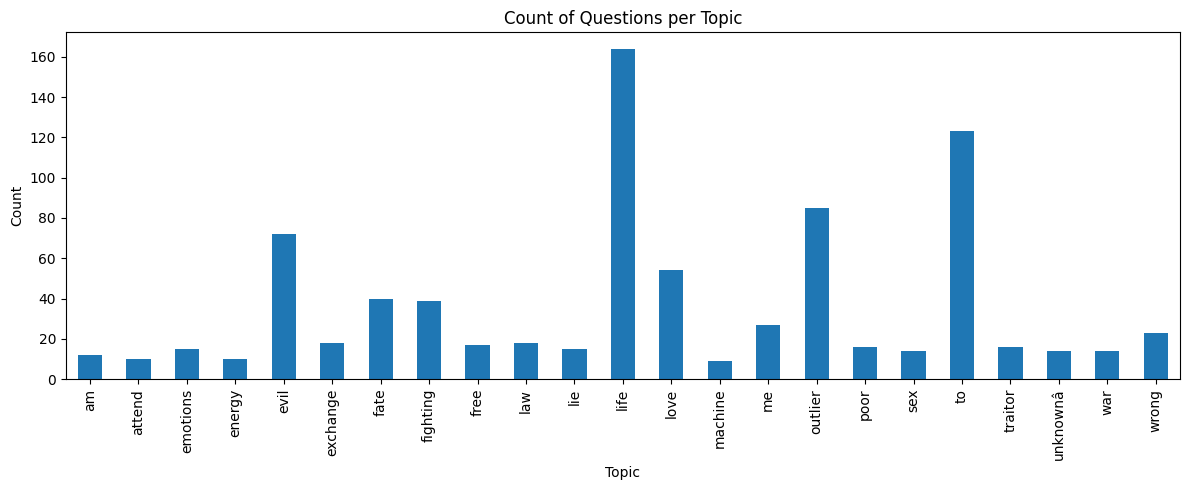

In [99]:
def visualize_new_labels(curr_df):

    label_counts = curr_df["Topic_Label"].value_counts().sort_index()

    plt.figure(figsize=(12, 5))
    label_counts.plot(kind="bar")
    plt.title("Count of Questions per Topic")
    plt.xlabel("Topic")
    plt.ylabel("Count")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

visualize_new_labels(df_sentences)

In [54]:
topic_model.get_topic(25)

[('contact', np.float64(0.13130322126695626)),
 ('family', np.float64(0.08641188040863233)),
 ('cut', np.float64(0.07541945742369396)),
 ('toxic', np.float64(0.07541945742369396)),
 ('parent', np.float64(0.06798414971525249)),
 ('member', np.float64(0.06606403151974508)),
 ('stranger', np.float64(0.058831533503104744)),
 ('abusive', np.float64(0.055273101610756915)),
 ('off', np.float64(0.052521288506782504)),
 ('limit', np.float64(0.05027963828246265))]

In [55]:
topic_model.get_representative_docs(25)

['Is it acceptable to limit contact with a toxic family member, even during holidays and important events?',
 '“Is it wrong to cut off contact with a toxic family member?”',
 'Is it wrong to cut off contact with a toxic parent, even if it means losing the rest of the family too?']

In [ ]:
df_sentences["Topic_Label"] = df_sentences["Topic_Label"].replace({
    "it": "lie",
    "my": "family", 
    "uploaded": "technology",
    "witness": "integrity"
})

In [ ]:
# Keep only the fields you want to share
export_df = df_sentences[["Question", "Topics", "Topic_Label"]].copy()

# Save detailed rows
export_df.to_csv("sementic_clusters_pof_questions.csv", index=False, encoding="utf-8")

# Optional: save summary counts
summary_df = (
    export_df.groupby(["Topics", "Topic_Label"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
    .sort_values("Count", ascending=False)
)
summary_df.to_csv("topic_summary.csv", index=False, encoding="utf-8")

In [ ]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Summary for chart
plot_df = (
    df_sentences.groupby(["Topics", "Topic_Label"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
    .sort_values("Count", ascending=False)
)

# Bar chart
bar = px.bar(
    plot_df.sort_values("Topics"),
    x="Topic_Label",
    y="Count",
    hover_data=["Topics"],
    title="Question Count by Topic Label"
)
bar.update_layout(xaxis_tickangle=-45)

# Optional table preview (top 100 rows for readability)
table_df = df_sentences[["Question", "Topics", "Topic_Label"]].head(100)

fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.12,
    row_heights=[0.55, 0.45],
    specs=[[{"type": "xy"}], [{"type": "table"}]],
    subplot_titles=("Topic Counts", "Sample Rows (Top 100)")
)

for tr in bar.data:
    fig.add_trace(tr, row=1, col=1)

fig.add_trace(
    go.Table(
        header=dict(values=list(table_df.columns)),
        cells=dict(values=[table_df[c] for c in table_df.columns])
    ),
    row=2, col=1
)

fig.update_layout(height=900, title="BERTopic Results Dashboard")
fig.write_html("topic_dashboard.html", include_plotlyjs="cdn")
fig.show()

In [ ]:
import json
from html import escape

def create_html_visualization(curr_df, curr_output_file):
  # 1) Build grouped data: Topic_Label -> list of questions
  grouped = (
      curr_df[["Topic_Label", "Question"]]
      .fillna({"Topic_Label": "outlier"})
      .groupby("Topic_Label")["Question"]
      .apply(list)
      .to_dict()
  )

  # Optional: sort categories by number of questions (largest first)
  grouped = dict(sorted(grouped.items(), key=lambda kv: len(kv[1]), reverse=True))

  # 2) Prepare chart data
  labels = list(grouped.keys())
  counts = [len(grouped[label]) for label in labels]

  # 3) Build HTML blocks (no subcategories, only categories -> questions)
  sections_html = []
  for label, questions in grouped.items():
      q_items = "\n".join(f"<li>{escape(q)}</li>" for q in questions)
      section = f"""
      <details class="category">
        <summary>
          <span class="name">{escape(str(label))}</span>
          <span class="count">{len(questions)} questions</span>
        </summary>
        <ul>
          {q_items}
        </ul>
      </details>
      """
      sections_html.append(section)

  sections_html = "\n".join(sections_html)

  # 4) Full HTML page
  html_text = f"""<!DOCTYPE html>
  <html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>Topic Questions Dashboard</title>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
      body {{
        margin: 0;
        font-family: "Segoe UI", Tahoma, sans-serif;
        background: #f5f7fb;
        color: #1f2937;
      }}
      .container {{
        max-width: 1100px;
        margin: 24px auto;
        background: #fff;
        border-radius: 12px;
        box-shadow: 0 8px 24px rgba(0,0,0,0.08);
        overflow: hidden;
      }}
      .header {{
        background: #1e3a8a;
        color: white;
        padding: 20px 24px;
      }}
      .header h1 {{
        margin: 0;
        font-size: 24px;
      }}
      .header p {{
        margin: 8px 0 0 0;
        opacity: 0.9;
      }}
      .content {{
        padding: 20px 24px;
      }}
      .category {{
        border: 1px solid #e5e7eb;
        border-radius: 10px;
        margin-bottom: 12px;
        background: #fafafa;
      }}
      summary {{
        cursor: pointer;
        list-style: none;
        display: flex;
        justify-content: space-between;
        align-items: center;
        padding: 14px 16px;
        font-weight: 600;
      }}
      summary::-webkit-details-marker {{
        display: none;
      }}
      .count {{
        font-size: 12px;
        color: #374151;
        background: #dbeafe;
        padding: 4px 8px;
        border-radius: 999px;
      }}
      ul {{
        margin: 0;
        padding: 0 24px 16px 40px;
      }}
      li {{
        margin: 6px 0;
        line-height: 1.45;
      }}
      .chart-wrap {{
        margin-top: 28px;
        border-top: 2px solid #e5e7eb;
        padding-top: 20px;
      }}
      .chart-title {{
        margin: 0 0 12px 0;
        font-size: 18px;
        font-weight: 700;
      }}
      .footer {{
        padding: 14px 24px 20px 24px;
        color: #6b7280;
        font-size: 12px;
      }}
    </style>
  </head>
  <body>
    <div class="container">
      <div class="header">
        <h1>Questions by Topic</h1>
        <p>Total Questions: {sum(counts)} | Total Topics: {len(labels)}</p>
      </div>

      <div class="content">
        {sections_html}

        <div class="chart-wrap">
          <h2 class="chart-title">Question Count by Topic</h2>
          <canvas id="topicChart" height="100"></canvas>
        </div>
      </div>

      <div class="footer">
        Generated from df_sentences (Question, Topics, Topic_Label)
      </div>
    </div>

    <script>
      const labels = {json.dumps(labels)};
      const counts = {json.dumps(counts)};

      const ctx = document.getElementById("topicChart");
      new Chart(ctx, {{
        type: "bar",
        data: {{
          labels: labels,
          datasets: [{{
            label: "Questions",
            data: counts
          }}]
        }},
        options: {{
          responsive: true,
          plugins: {{
            legend: {{ display: false }}
          }},
          scales: {{
            x: {{
              ticks: {{
                maxRotation: 70,
                minRotation: 45
              }}
            }},
            y: {{
              beginAtZero: true
            }}
          }}
        }}
      }});
    </script>
  </body>
  </html>
  """

  # 5) Save file
  with open(curr_output_file, "w", encoding="utf-8") as f:
      f.write(html_text)

  print(f"Saved: {curr_output_file}")

create_html_visualization(df_sentences, "topic_questions_visualizations")

Saved: topic_questions_visualizations


DALLIN's DATASET NOW BEING USED


In [69]:
with open("dallin_questions.txt", "r", encoding="utf-8") as f:
    dallin_uncleaned_sentences = f.read().splitlines()
    dallin_sentences = clean_txt(dallin_uncleaned_sentences)

len(dallin_sentences)

773

In [86]:
d_topics, probs = topic_model.fit_transform(dallin_sentences)

In [87]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,115,-1_to_and_the_what,"[to, and, the, what, of, my, in, it, is, right]",[Why does someone born on one side of the worl...
1,0,398,0_life_what_the_is,"[life, what, the, is, of, why, meaning, how, d...","[What is the meaning of a human life?, what is..."
2,1,66,1_to_children_it_would,"[to, children, it, would, and, save, ethical, ...",[Is it ethical to steal an unaffordable medici...
3,2,20,2_evil_good_bad_complex,"[evil, good, bad, complex, acts, inherently, w...","[Based on what you know, can good exist withou..."
4,3,16,3_love_me_for_someone,"[love, me, for, someone, loving, to, it, judgm...",[Is it wrong of me to want things to go bad fo...
5,4,15,4_fate_destiny_predetermined_believe,"[fate, destiny, predetermined, believe, in, re...","[Is everyone's destiny predetermined?, Should ..."
6,5,14,5_fighting_perhaps_return_win,"[fighting, perhaps, return, win, half, battle,...",[There's something very strange: the fighting ...
7,6,13,6_forgive_my_betrayed_regrets,"[forgive, my, betrayed, regrets, resentment, d...",[If the Russian hacker revealed his identity a...
8,7,12,7_wrong_real_watching_fantasies,"[wrong, real, watching, fantasies, as, out, lo...",[Is it okay for fantasies to exist as long as ...
9,8,10,8_compassion_poor_why_cry,"[compassion, poor, why, cry, did, while, peopl...","[Can you help me answer Freudâ€™s question, 'W..."


In [88]:
new_d_topics = topic_model.reduce_outliers(
dallin_sentences,
d_topics,
strategy="embeddings",
threshold=0.15
)
topic_model.update_topics(dallin_sentences, topics=new_d_topics)

2026-04-15 13:49:03,773 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [101]:
df_dallin_sentences = pd.DataFrame({"Topics": d_topics, "Question": dallin_sentences})
df_dallin_sentences["Topics"] = new_d_topics   
df_dallin_sentences.head(10)

,Topics,Question
0,0,Why so much suffering?
1,18,Can I be racist?
2,1,Is it wrong to steal to feed your family?
3,15,Is there such a thing as a good lie?
4,0,Does an afterlife exist?
5,0,What happens to a person after they die?
6,1,What is the essence of having children?
7,0,What is life?
8,0,Why did we come into this world?
9,0,Why did I come into the world?


In [102]:
topic_model.get_topic_info()

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,1,-1_paid_blood_do_have,happiness,"[paid, blood, do, have, to, for, be, in, what, ]",[Why does someone born on one side of the worl...
1,0,434,0_life_what_the_is,life,"[life, what, the, is, of, why, and, how, do, m...","[What is the meaning of a human life?, what is..."
2,1,85,1_to_it_children_the,to,"[to, it, children, the, save, and, be, would, ...",[Is it ethical to steal an unaffordable medici...
3,2,22,2_evil_good_bad_acts,evil,"[evil, good, bad, acts, people, complex, what,...","[Based on what you know, can good exist withou..."
4,3,21,3_love_me_for_someone,love,"[love, me, for, someone, it, loving, to, bad, ...",[Is it wrong of me to want things to go bad fo...
5,4,17,4_fate_destiny_predetermined_believe,fate,"[fate, destiny, predetermined, believe, is, in...","[Is everyone's destiny predetermined?, Should ..."
6,5,16,5_fighting_perhaps_return_win,fighting,"[fighting, perhaps, return, win, half, battle,...",[There's something very strange: the fighting ...
7,6,21,6_me_forgive_my_was,me,"[me, forgive, my, was, should, it, regrets, re...",[If the Russian hacker revealed his identity a...
8,7,15,7_wrong_real_fantasies_watching,wrong,"[wrong, real, fantasies, watching, as, out, lo...",[Is it okay for fantasies to exist as long as ...
9,8,17,8_poor_compassion_person_why,poor,"[poor, compassion, person, why, deserve, peopl...","[Can you help me answer Freudâ€™s question, 'W..."


In [103]:
topic_model.get_representative_docs(-1)

['Why does someone born on one side of the world have more right than someone born on the other for life to go well?',
 "After a powerful early-morning hallucination in which I saw and felt things, heard a voice in English say 'there is the plus and minus and thatâ€™s how it will always be,' and then something green came to my heart, exploded, the whole room turned green, and I felt peaceâ€”what was that?",
 "I had a very powerful hallucination early in the morning: I saw and felt things, heard a voice in English say, 'there is the plus and minus and thatâ€™s how it will always be,' and then something green came into my heart, exploded, and the whole room seemed green; I felt peace. How could that have happened?"]

In [92]:
topic_model.visualize_topics()

In [95]:
topic_model.visualize_barchart(top_n_topics=21)

In [104]:
define_labels_for_topics(df_dallin_sentences)

,Topics,Topic_Label
327,-1,outlier
0,0,life
2,1,to
25,2,evil
68,3,love
38,4,fate
23,5,fighting
47,6,me
14,7,wrong
21,8,poor


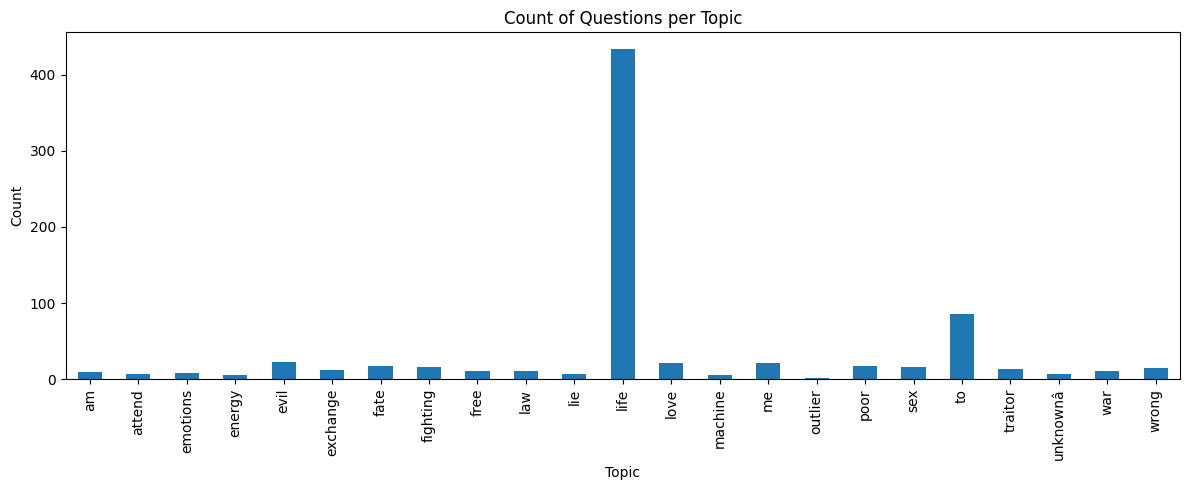

In [105]:
visualize_new_labels(df_dallin_sentences)

In [114]:
topic_model.get_topic(7)

[('wrong', np.float64(0.09721810494310547)),
 ('real', np.float64(0.09626124543034278)),
 ('fantasies', np.float64(0.07371845662992013)),
 ('watching', np.float64(0.07371845662992013)),
 ('as', np.float64(0.0716248238853223)),
 ('out', np.float64(0.05775674725820567)),
 ('looking', np.float64(0.05309902355102373)),
 ('plane', np.float64(0.05309902355102373)),
 ('infidelity', np.float64(0.04914563775328008)),
 ('aren', np.float64(0.04914563775328008))]

In [115]:
topic_model.get_representative_docs(7)

["Is it okay for fantasies to exist as long as they aren't carried out in real life?",
 'As an artist, if I draw fantasies that would be wrong to carry out in real life but remain only drawings, would drawing them be wrong in itself?',
 "Are fantasies morally okay as long as they aren't acted out in real life?"]

In [120]:
topic_label_overrides = {
    7: "identity",
    3: "death",
    12: "forgive",
}

df_dallin_sentences["Topic_Label"] = (
    df_dallin_sentences["Topics"]
    .map(topic_label_overrides)
    .fillna(df_dallin_sentences["Topic_Label"])
)

In [122]:
import json
from html import escape
create_html_visualization(df_dallin_sentences, "dallin_categories_visualization.html")

Saved: dallin_categories_visualization.html
